# Notebook 04: Multi-Head Attention

Multi-head attention runs several attention heads in parallel, allowing the model to jointly attend to information from different representation subspaces.

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W_O$$
$$\text{where head}_i = \text{Attention}(XW_Q^i, XW_K^i, XW_V^i)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
def softmax(x):
    """Numerically stable softmax along last axis."""
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def causal_mask(seq_len):
    """Create causal (upper triangular) mask."""
    mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
    return mask[np.newaxis, np.newaxis, :, :]  # (1, 1, T, T) for broadcasting

## 1. Multi-Head Attention Implementation

Key idea: instead of one attention function with $d_{model}$-dimensional keys, values, and queries, we project them $h$ times with different learned projections to $d_k = d_{model}/h$ dimensions each, perform attention in parallel, then concatenate and project.

Our config: $d_{model}=64$, $h=4$ heads, $d_k=16$ per head.

In [3]:
class MultiHeadAttention:
    """Multi-head attention with full backpropagation."""
    
    def __init__(self, d_model, n_heads):
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # dimension per head
        
        scale = np.sqrt(2.0 / (d_model + self.d_k))
        # Combined projection matrices for all heads
        self.W_Q = np.random.randn(d_model, d_model) * scale
        self.W_K = np.random.randn(d_model, d_model) * scale
        self.W_V = np.random.randn(d_model, d_model) * scale
        self.W_O = np.random.randn(d_model, d_model) * scale
        
        # Gradients
        self.dW_Q = None
        self.dW_K = None
        self.dW_V = None
        self.dW_O = None
        
        # Cache
        self.x = None
        self.Q = None
        self.K = None
        self.V = None
        self.attn_weights = None
        self.attn_output = None  # before W_O projection
    
    def _split_heads(self, x):
        """Reshape (B, T, d_model) -> (B, n_heads, T, d_k)"""
        B, T, D = x.shape
        return x.reshape(B, T, self.n_heads, self.d_k).transpose(0, 2, 1, 3)
    
    def _merge_heads(self, x):
        """Reshape (B, n_heads, T, d_k) -> (B, T, d_model)"""
        B, H, T, d_k = x.shape
        return x.transpose(0, 2, 1, 3).reshape(B, T, self.d_model)
    
    def forward(self, x, mask=None):
        """Forward pass.
        
        Args:
            x: input of shape (B, T, d_model)
            mask: causal mask of shape (1, 1, T, T)
        Returns:
            output of shape (B, T, d_model)
        """
        self.x = x
        B, T, D = x.shape
        
        # Linear projections
        Q = x @ self.W_Q  # (B, T, d_model)
        K = x @ self.W_K
        V = x @ self.W_V
        
        # Split into heads: (B, n_heads, T, d_k)
        self.Q = self._split_heads(Q)
        self.K = self._split_heads(K)
        self.V = self._split_heads(V)
        
        # Scaled dot-product attention
        scores = (self.Q @ self.K.transpose(0, 1, 3, 2)) / np.sqrt(self.d_k)  # (B, H, T, T)
        
        if mask is not None:
            scores = np.where(mask, -1e9, scores)
        
        self.attn_weights = softmax(scores)  # (B, H, T, T)
        
        # Weighted sum of values
        attn_out = self.attn_weights @ self.V  # (B, H, T, d_k)
        
        # Merge heads: (B, T, d_model)
        self.attn_output = self._merge_heads(attn_out)
        
        # Output projection
        output = self.attn_output @ self.W_O
        return output
    
    def backward(self, dout):
        """Backward pass.
        
        Args:
            dout: gradient of shape (B, T, d_model)
        Returns:
            dx: gradient w.r.t. input, shape (B, T, d_model)
        """
        B, T, D = dout.shape
        
        # Gradient through output projection
        self.dW_O = self.attn_output.reshape(-1, D).T @ dout.reshape(-1, D)
        d_attn_output = dout @ self.W_O.T  # (B, T, d_model)
        
        # Reshape back to heads: (B, H, T, d_k)
        d_attn_out = self._split_heads(d_attn_output)
        
        # Gradient through attn_weights @ V
        d_attn_weights = d_attn_out @ self.V.transpose(0, 1, 3, 2)  # (B, H, T, T)
        dV = self.attn_weights.transpose(0, 1, 3, 2) @ d_attn_out   # (B, H, T, d_k)
        
        # Gradient through softmax
        sum_term = np.sum(d_attn_weights * self.attn_weights, axis=-1, keepdims=True)
        d_scores = self.attn_weights * (d_attn_weights - sum_term)
        d_scores /= np.sqrt(self.d_k)
        
        # Gradient through Q @ K^T
        dQ = d_scores @ self.K                        # (B, H, T, d_k)
        dK = d_scores.transpose(0, 1, 3, 2) @ self.Q  # (B, H, T, d_k)
        
        # Merge heads back: (B, T, d_model)
        dQ = self._merge_heads(dQ)
        dK = self._merge_heads(dK)
        dV = self._merge_heads(dV)
        
        # Gradient through linear projections
        x_flat = self.x.reshape(-1, D)
        self.dW_Q = x_flat.T @ dQ.reshape(-1, D)
        self.dW_K = x_flat.T @ dK.reshape(-1, D)
        self.dW_V = x_flat.T @ dV.reshape(-1, D)
        
        # Gradient through input
        dx = dQ @ self.W_Q.T + dK @ self.W_K.T + dV @ self.W_V.T
        return dx

print("MultiHeadAttention defined.")

MultiHeadAttention defined.


## 2. Testing Multi-Head Attention

In [4]:
d_model = 64
n_heads = 4
B, T = 2, 8

mha = MultiHeadAttention(d_model, n_heads)
x = np.random.randn(B, T, d_model)
mask = causal_mask(T)

# Forward
output = mha.forward(x, mask=mask)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {mha.attn_weights.shape} (batch, heads, T, T)")

# Backward
dout = np.random.randn(B, T, d_model)
dx = mha.backward(dout)
print(f"\ndx shape:    {dx.shape}")
print(f"dW_Q shape:  {mha.dW_Q.shape}")
print(f"dW_O shape:  {mha.dW_O.shape}")

Input shape:  (2, 8, 64)
Output shape: (2, 8, 64)
Attention weights shape: (2, 4, 8, 8) (batch, heads, T, T)

dx shape:    (2, 8, 64)
dW_Q shape:  (64, 64)
dW_O shape:  (64, 64)


## 3. Visualize Attention Heads

Each head can learn to attend to different patterns.

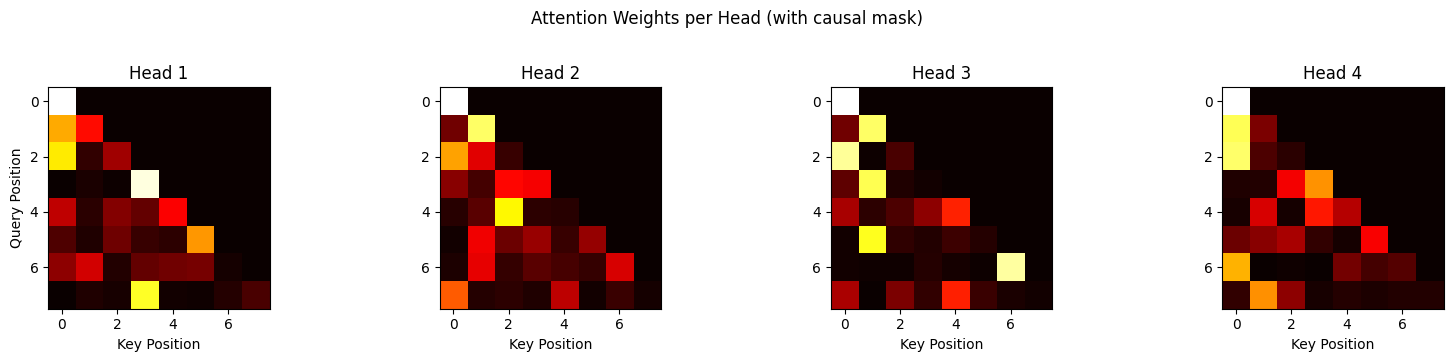

Each head shows a different attention pattern, all respecting the causal mask.


In [5]:
# Visualize all 4 attention heads for the first sample
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for h in range(n_heads):
    im = axes[h].imshow(mha.attn_weights[0, h], cmap='hot', vmin=0, vmax=1)
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Key Position')
    if h == 0:
        axes[h].set_ylabel('Query Position')
plt.suptitle('Attention Weights per Head (with causal mask)', y=1.02)
plt.tight_layout()
plt.show()
print("Each head shows a different attention pattern, all respecting the causal mask.")

## 4. Gradient Checking

In [6]:
def numerical_gradient(f, x, eps=1e-5):
    """Compute numerical gradient using central differences."""
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        old_val = x[idx]
        x[idx] = old_val + eps
        fp = f(x)
        x[idx] = old_val - eps
        fm = f(x)
        grad[idx] = (fp - fm) / (2 * eps)
        x[idx] = old_val
        it.iternext()
    return grad

def relative_error(a, b):
    return np.max(np.abs(a - b) / (np.maximum(np.abs(a) + np.abs(b), 1e-8)))

# Use small dimensions for tractable gradient checking
np.random.seed(42)
d_model, n_heads = 8, 2
B, T = 2, 4
mha = MultiHeadAttention(d_model, n_heads)
x = np.random.randn(B, T, d_model)
mask = causal_mask(T)
dout = np.random.randn(B, T, d_model)

# Forward + backward
output = mha.forward(x, mask=mask)
dx = mha.backward(dout)

# Check each weight matrix
for name, W, dW in [
    ('W_Q', mha.W_Q, mha.dW_Q),
    ('W_K', mha.W_K, mha.dW_K),
    ('W_V', mha.W_V, mha.dW_V),
    ('W_O', mha.W_O, mha.dW_O),
]:
    def loss_fn(W_val, name=name):
        setattr(mha, name, W_val)
        out = mha.forward(x, mask=mask)
        return np.sum(out * dout)
    
    num_grad = numerical_gradient(loss_fn, W.copy())
    err = relative_error(dW, num_grad)
    print(f"{name} gradient error: {err:.2e} {'PASS' if err < 1e-5 else 'FAIL'}")

# Check input gradient
def loss_x(x_in):
    out = mha.forward(x_in, mask=mask)
    return np.sum(out * dout)

num_grad_x = numerical_gradient(loss_x, x.copy())
err_x = relative_error(dx, num_grad_x)
print(f"x gradient error:   {err_x:.2e} {'PASS' if err_x < 1e-5 else 'FAIL'}")

W_Q gradient error: 2.92e-09 PASS
W_K gradient error: 5.19e-09 PASS
W_V gradient error: 1.39e-08 PASS
W_O gradient error: 1.28e-09 PASS
x gradient error:   6.71e-10 PASS


## Summary

We've built:
- **Multi-head attention** with head splitting/merging and output projection
- Full **backward pass** through all operations
- **Visualization** of per-head attention patterns
- **Gradient checking** confirming correctness

Next notebook: **FFN and LayerNorm**, the other components of a transformer block.